In [68]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Continual World Results

In [69]:
cw_cpo_0 = pd.read_csv('./results/cw/cpo_0.csv')
cw_cpo_1 = pd.read_csv('./results/cw/cpo_1.csv')
cw_cpo_2 = pd.read_csv('./results/cw/cpo_2.csv')
cw_cpo_3 = pd.read_csv('./results/cw/cpo_3.csv')
cw_cpo_4 = pd.read_csv('./results/cw/cpo_4.csv')

cpo_list = [cw_cpo_0, cw_cpo_1, cw_cpo_2, cw_cpo_3, cw_cpo_4]

cw_cpo_rewards = [results['Metrics/EpSuccess'] for results in cpo_list]
cw_cpo_costs = [results['Metrics/EpCost'] for results in cpo_list]

cw_cpo_mean_rewards = np.mean(cw_cpo_rewards, axis=0)
cw_cpo_mean_costs = np.mean(cw_cpo_costs, axis=0)

cw_cpo_std_rewards = np.std(cw_cpo_rewards, axis=0)
cw_cpo_std_costs = np.std(cw_cpo_costs, axis=0)

In [70]:
cw_ppo_0 = pd.read_csv('./results/cw/ppo_0.csv')
cw_ppo_1 = pd.read_csv('./results/cw/ppo_1.csv')
cw_ppo_2 = pd.read_csv('./results/cw/ppo_2.csv')
cw_ppo_3 = pd.read_csv('./results/cw/ppo_3.csv')
cw_ppo_4 = pd.read_csv('./results/cw/ppo_4.csv')

ppo_list = [cw_ppo_0, cw_ppo_1, cw_ppo_2, cw_ppo_3, cw_ppo_4]

cw_ppo_rewards = [results['Metrics/EpSuccess'] for results in ppo_list]
cw_ppo_costs = [results['Metrics/EpCost'] for results in ppo_list]

cw_ppo_mean_rewards = np.mean(cw_ppo_rewards, axis=0)
cw_ppo_mean_costs = np.mean(cw_ppo_costs, axis=0)

cw_ppo_std_rewards = np.std(cw_ppo_rewards, axis=0)
cw_ppo_std_costs = np.std(cw_ppo_costs, axis=0)

In [71]:
cw_ppolag_0 = pd.read_csv('./results/cw/ppo_lag_0.csv')
cw_ppolag_1 = pd.read_csv('./results/cw/ppo_lag_1.csv')
cw_ppolag_2 = pd.read_csv('./results/cw/ppo_lag_2.csv')
cw_ppolag_3 = pd.read_csv('./results/cw/ppo_lag_3.csv')
cw_ppolag_4 = pd.read_csv('./results/cw/ppo_lag_4.csv')

ppolag_list = [cw_ppolag_0, cw_ppolag_1, cw_ppolag_2, cw_ppolag_3, cw_ppolag_4]

cw_ppolag_rewards = [results['Metrics/EpSuccess'] for results in ppolag_list]
cw_ppolag_costs = [results['Metrics/EpCost'] for results in ppolag_list]

cw_ppolag_mean_rewards = np.mean(cw_ppolag_rewards, axis=0)
cw_ppolag_mean_costs = np.mean(cw_ppolag_costs, axis=0)

cw_ppolag_std_rewards = np.std(cw_ppolag_rewards, axis=0)
cw_ppolag_std_costs = np.std(cw_ppolag_costs, axis=0)

In [72]:
cw_cppo_pid_0 = pd.read_csv('./results/cw/cppo_pid_0.csv')
cw_cppo_pid_1 = pd.read_csv('./results/cw/cppo_pid_1.csv')
cw_cppo_pid_2 = pd.read_csv('./results/cw/cppo_pid_2.csv')
cw_cppo_pid_3 = pd.read_csv('./results/cw/cppo_pid_3.csv')
cw_cppo_pid_4 = pd.read_csv('./results/cw/cppo_pid_4.csv')

cppo_pid_list = [cw_cppo_pid_0, cw_cppo_pid_1, cw_cppo_pid_2, cw_cppo_pid_3, cw_cppo_pid_4]

cw_cppo_pid_rewards = [results['Metrics/EpSuccess'] for results in cppo_pid_list]
cw_cppo_pid_costs = [results['Metrics/EpCost'] for results in cppo_pid_list]

cw_cppo_pid_mean_rewards = np.mean(cw_cppo_pid_rewards, axis=0)
cw_cppo_pid_mean_costs = np.mean(cw_cppo_pid_costs, axis=0)

cw_cppo_pid_std_rewards = np.std(cw_cppo_pid_rewards, axis=0)
cw_cppo_pid_std_costs = np.std(cw_cppo_pid_costs, axis=0)

In [73]:
cw_clear_0 = pd.read_csv('./results/cw/clear_0.csv')
# cw_clear_1 = pd.read_csv('./results/cw/clear_1.csv')
# cw_clear_2 = pd.read_csv('./results/cw/clear_2.csv')
# cw_clear_3 = pd.read_csv('./results/cw/clear_3.csv')
# cw_clear_4 = pd.read_csv('./results/cw/clear_4.csv')

clear_list = [cw_clear_0] #TODO: rerun clear with seed 1-4

cw_clear_rewards = [results['Metrics/EpSuccess'] for results in clear_list]
cw_clear_costs = [results['Metrics/EpCost'] for results in clear_list]

cw_clear_mean_rewards = np.mean(cw_clear_rewards, axis=0)
cw_clear_mean_costs = np.mean(cw_clear_costs, axis=0)

cw_clear_std_rewards = np.std(cw_clear_rewards, axis=0)
cw_clear_std_costs = np.std(cw_clear_costs, axis=0)

In [74]:
def aggregate_metrics(results_list, task_sequence, task_length):
    hammer_costs, push_wall_costs, faucet_costs, push_back_costs, stick_pull_costs = [], [], [], [], []
    hammer_forgets, push_wall_forgets, faucet_forgets, push_back_forgets, stick_pull_forgets = [], [], [], [], []
    hammer_rew_forgets, push_wall_rew_forgets, faucet_rew_forgets, push_back_rew_forgets, stick_pull_rew_forgets = [], [], [], [], []
    hammer_rewards, push_wall_rewards, faucet_rewards, push_back_rewards, stick_pull_rewards = [], [], [], [], []

    for result in results_list:
        hammer_cost, push_wall_cost, faucet_cost, push_back_cost, stick_pull_cost, \
        hammer_forget, push_wall_forget, faucet_forget, push_back_forget, stick_pull_forget, \
        hammer_rew, push_wall_rew, faucet_rew, push_back_rew, stick_pull_rew, \
        hammer_rew_forget, push_wall_rew_forget, faucet_rew_forget, push_back_rew_forget, stick_pull_rew_forget = calculate_metrics(result, task_sequence, task_length)

        hammer_costs.append(hammer_cost)
        push_wall_costs.append(push_wall_cost)
        faucet_costs.append(faucet_cost)
        push_back_costs.append(push_back_cost)
        stick_pull_costs.append(stick_pull_cost)
        
        hammer_forgets.append(hammer_forget)
        push_wall_forgets.append(push_wall_forget)
        faucet_forgets.append(faucet_forget)
        push_back_forgets.append(push_back_forget)
        stick_pull_forgets.append(stick_pull_forget)
        
        hammer_rewards.append(hammer_rew)
        push_wall_rewards.append(push_wall_rew)
        faucet_rewards.append(faucet_rew)
        push_back_rewards.append(push_back_rew)
        stick_pull_rewards.append(stick_pull_rew)
        
        hammer_rew_forgets.append(hammer_rew_forget)
        push_wall_rew_forgets.append(push_wall_rew_forget)
        faucet_rew_forgets.append(faucet_rew_forget)
        push_back_rew_forgets.append(push_back_rew_forget)
        stick_pull_rew_forgets.append(stick_pull_rew_forget)

    tasks = ['hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull']
    cost_lists = [hammer_costs, push_wall_costs, faucet_costs, push_back_costs, stick_pull_costs]
    forget_lists = [hammer_forgets, push_wall_forgets, faucet_forgets, push_back_forgets, stick_pull_forgets]
    reward_lists = [hammer_rewards, push_wall_rewards, faucet_rewards, push_back_rewards, stick_pull_rewards]
    rew_forget_lists = [hammer_rew_forgets, push_wall_rew_forgets, faucet_rew_forgets, push_back_rew_forgets, stick_pull_rew_forgets]

    for task, costs, forgets, rewards, rew_forgets in zip(tasks, cost_lists, forget_lists, reward_lists, rew_forget_lists):
        print(f"{task.upper()}:")
        print(f"Total costs: {np.mean(costs)} +/- {np.std(costs)}")
        print(f"Forgetting ratio: {np.mean(forgets)} +/- {np.std(forgets)}")
        print(f"Reward forgetting: {np.mean(rew_forgets)} +/- {np.std(rew_forgets)}")
        print(f"Rewards: {np.mean(rewards)} +/- {np.std(rewards)}")
        print()

    initial = [r['Metrics/EpRet'][0] for r in results_list]
    possible_forgetting = np.mean([np.mean(lst) for lst in reward_lists]) - np.mean(initial)
    print(np.mean(initial), possible_forgetting)
    norm_forget = np.mean([np.mean(lst) for lst in rew_forget_lists]) / possible_forgetting
    print('NORMALIZED FORGETTING:')
    print(norm_forget)

def calculate_metrics(results, task_sequence, task_length):
    results = add_task_names(results, task_sequence, task_length)
    hammer_cost, push_wall_cost, faucet_cost, push_back_cost, stick_pull_cost = all_average_total_costs(results, task_length)
    hammer_forget, push_wall_forget, faucet_forget, push_back_forget, stick_pull_forget, hammer_rew_forget, push_wall_rew_forget, faucet_rew_forget, push_back_rew_forget, stick_pull_rew_forget = all_forgetting(results, task_length)
    hammer_rew, push_wall_rew, faucet_rew, push_back_rew, stick_pull_rew = all_rewards(results, task_length)
    return hammer_cost, push_wall_cost, faucet_cost, push_back_cost, stick_pull_cost, hammer_forget, push_wall_forget, faucet_forget, push_back_forget, stick_pull_forget, hammer_rew, push_wall_rew, faucet_rew, push_back_rew, stick_pull_rew, hammer_rew_forget, push_wall_rew_forget, faucet_rew_forget, push_back_rew_forget, stick_pull_rew_forget

def add_task_names(results, task_sequence, task_length):
    task_names = [[task] * task_length for task in task_sequence]
    task_names = np.concatenate(task_names)
    results['task'] = task_names

    return results

def all_average_total_costs(results, task_length):
    hammer_cost = average_total_costs(results, 'hammer', task_length)
    push_wall_cost = average_total_costs(results, 'push-wall', task_length)
    faucet_cost = average_total_costs(results, 'faucet', task_length)
    push_back_cost = average_total_costs(results, 'push-back', task_length)
    stick_pull_cost = average_total_costs(results, 'stick-pull', task_length)

    return hammer_cost, push_wall_cost, faucet_cost, push_back_cost, stick_pull_cost

def average_total_costs(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_costs = task_results['Metrics/EpCost'].to_numpy()

    num_visited = int(len(task_costs) / task_length)

    total_costs = []
    for i in range(num_visited):
        task_idx = np.arange(0, task_length) + i * task_length
        total_costs.append(task_costs[task_idx].sum())

    return np.mean(total_costs)

def all_forgetting(results, task_length):
    hammer_forget, hammer_rew_forget = forgetting(results, 'hammer', task_length)
    push_wall_forget, push_wall_rew_forget = forgetting(results, 'push-wall', task_length)
    faucet_forget, faucet_rew_forget = forgetting(results, 'faucet', task_length)
    push_back_forget, push_back_rew_forget = forgetting(results, 'push-back', task_length)
    stick_pull_forget, stick_pull_rew_forget = forgetting(results, 'stick-pull', task_length)

    return hammer_forget, push_wall_forget, faucet_forget, push_back_forget, stick_pull_forget, hammer_rew_forget, push_wall_rew_forget, faucet_rew_forget, push_back_rew_forget, stick_pull_rew_forget

def forgetting(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_rewards = task_results['Metrics/EpRet'].to_numpy()

    endpoint = task_length - 1
    startpoint = task_length + 1 # to purge the buffer

    num_visited = int(len(task_rewards) / task_length)
    num_restart = num_visited - 1

    forget_values = []
    abs_forget = []
    for i in range(num_restart):
        A = task_rewards[endpoint * (i+1)]
        B = task_rewards[startpoint * (i+1)]
        forget = (A - B) / (np.abs(A)) * 100

        forget_values.append(forget)
        abs_forget.append(A-B)
    
    return np.mean(forget_values), np.mean(abs_forget)

def all_rewards(results, task_length):
    hammer_rew = rewards(results, 'hammer', task_length)
    push_wall_rew = rewards(results, 'push-wall', task_length)
    faucet_rew = rewards(results, 'faucet', task_length)
    push_back_rew = rewards(results, 'push-back', task_length)
    stick_pull_rew = rewards(results, 'stick-pull', task_length)

    return hammer_rew, push_wall_rew, faucet_rew, push_back_rew, stick_pull_rew


def rewards(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_rewards = task_results['Metrics/EpRet'].to_numpy()

    endpoint = task_length - 1

    num_visited = int(len(task_rewards) / task_length)

    reward_vals = []
    for i in range(num_visited):
        rew = task_rewards[endpoint * (i+1)]
        reward_vals.append(rew)
    
    return reward_vals[-1]
    

In [75]:
def all_success_rates(results, task_length):
    hammer_success_rate = success_rate(results, 'hammer', task_length)
    push_wall_success_rate = success_rate(results, 'push-wall', task_length)
    faucet_success_rate = success_rate(results, 'faucet', task_length)
    push_back_success_rate = success_rate(results, 'push-back', task_length)
    stick_pull_success_rate = success_rate(results, 'stick-pull', task_length)

    return hammer_success_rate, push_wall_success_rate, faucet_success_rate, push_back_success_rate, stick_pull_success_rate

def success_rate(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_success = task_results['Metrics/EpSuccess'].to_numpy()

    endpoint = task_length - 1

    num_visited = int(len(task_success) / task_length)

    success_vals = []
    for i in range(num_visited):
        success = task_success[endpoint * (i+1)]
        success_vals.append(success)
    
    return np.mean(success_vals)

def all_success_forgetting(results, task_length):
    hammer_success_forgetting_rate = success_forgetting(results, 'hammer', task_length)
    push_wall_success_forgetting_rate = success_forgetting(results, 'push-wall', task_length)
    faucet_success_forgetting_rate = success_forgetting(results, 'faucet', task_length)
    push_back_success_forgetting_rate = success_forgetting(results, 'push-back', task_length)
    stick_pull_success_forgetting_rate = success_forgetting(results, 'stick-pull', task_length)

    return hammer_success_forgetting_rate, push_wall_success_forgetting_rate, faucet_success_forgetting_rate, push_back_success_forgetting_rate, stick_pull_success_forgetting_rate

def success_forgetting(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_success = task_results['Metrics/EpSuccess'].to_numpy()

    endpoint = task_length - 1
    startpoint = task_length + 1 # to purge the buffer

    num_visited = int(len(task_success) / task_length)
    num_restart = num_visited - 1

    forget_values = []
    for i in range(num_restart):
        A = task_success[endpoint * (i+1)]
        B = task_success[startpoint * (i+1)]

        forget_values.append(A-B)
    
    return np.mean(forget_values)

def aggregate_metrics(results_list, task_sequence, task_length):
    hammer_costs, push_wall_costs, faucet_costs, push_back_costs, stick_pull_costs = [], [], [], [], []
    hammer_forgets, push_wall_forgets, faucet_forgets, push_back_forgets, stick_pull_forgets = [], [], [], [], []
    hammer_rew_forgets, push_wall_rew_forgets, faucet_rew_forgets, push_back_rew_forgets, stick_pull_rew_forgets = [], [], [], [], []
    hammer_rewards, push_wall_rewards, faucet_rewards, push_back_rewards, stick_pull_rewards = [], [], [], [], []
    hammer_success, push_wall_success, faucet_success, push_back_success, stick_pull_success = [], [], [], [], []
    hammer_success_forgetting, push_wall_success_forgetting, faucet_success_forgetting, push_back_success_forgetting, stick_pull_success_forgetting = [], [], [], [], []

    for result in results_list:
        hammer_cost, push_wall_cost, faucet_cost, push_back_cost, stick_pull_cost, \
        hammer_forget, push_wall_forget, faucet_forget, push_back_forget, stick_pull_forget, \
        hammer_rew, push_wall_rew, faucet_rew, push_back_rew, stick_pull_rew, \
        hammer_rew_forget, push_wall_rew_forget, faucet_rew_forget, push_back_rew_forget, stick_pull_rew_forget, \
        hammer_success_rate, push_wall_success_rate, faucet_success_rate, push_back_success_rate, stick_pull_success_rate, \
        hammer_success_forgetting_rate, push_wall_success_forgetting_rate, faucet_success_forgetting_rate, push_back_success_forgetting_rate, stick_pull_success_forgetting_rate = calculate_metrics(result, task_sequence, task_length)

        hammer_costs.append(hammer_cost)
        push_wall_costs.append(push_wall_cost)
        faucet_costs.append(faucet_cost)
        push_back_costs.append(push_back_cost)
        stick_pull_costs.append(stick_pull_cost)
        
        hammer_forgets.append(hammer_forget)
        push_wall_forgets.append(push_wall_forget)
        faucet_forgets.append(faucet_forget)
        push_back_forgets.append(push_back_forget)
        stick_pull_forgets.append(stick_pull_forget)
        
        hammer_rewards.append(hammer_rew)
        push_wall_rewards.append(push_wall_rew)
        faucet_rewards.append(faucet_rew)
        push_back_rewards.append(push_back_rew)
        stick_pull_rewards.append(stick_pull_rew)
        
        hammer_rew_forgets.append(hammer_rew_forget)
        push_wall_rew_forgets.append(push_wall_rew_forget)
        faucet_rew_forgets.append(faucet_rew_forget)
        push_back_rew_forgets.append(push_back_rew_forget)
        stick_pull_rew_forgets.append(stick_pull_rew_forget)
        
        hammer_success.append(hammer_success_rate)
        push_wall_success.append(push_wall_success_rate)
        faucet_success.append(faucet_success_rate)
        push_back_success.append(push_back_success_rate)
        stick_pull_success.append(stick_pull_success_rate)
        
        hammer_success_forgetting.append(hammer_success_forgetting_rate)
        push_wall_success_forgetting.append(push_wall_success_forgetting_rate)
        faucet_success_forgetting.append(faucet_success_forgetting_rate)
        push_back_success_forgetting.append(push_back_success_forgetting_rate)
        stick_pull_success_forgetting.append(stick_pull_success_forgetting_rate)

    tasks = ['hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull']
    cost_lists = [hammer_costs, push_wall_costs, faucet_costs, push_back_costs, stick_pull_costs]
    forget_lists = [hammer_forgets, push_wall_forgets, faucet_forgets, push_back_forgets, stick_pull_forgets]
    reward_lists = [hammer_rewards, push_wall_rewards, faucet_rewards, push_back_rewards, stick_pull_rewards]
    rew_forget_lists = [hammer_rew_forgets, push_wall_rew_forgets, faucet_rew_forgets, push_back_rew_forgets, stick_pull_rew_forgets]
    success_lists = [hammer_success, push_wall_success, faucet_success, push_back_success, stick_pull_success]
    success_forgetting_lists = [hammer_success_forgetting, push_wall_success_forgetting, faucet_success_forgetting, push_back_success_forgetting, stick_pull_success_forgetting]

    for task, costs, forgets, rewards, rew_forgets, success, success_forgetting in zip(tasks, cost_lists, forget_lists, reward_lists, rew_forget_lists, success_lists, success_forgetting_lists):
        print(f"{task.upper()}:")
        print(f"Total costs: {np.mean(costs)} +/- {np.std(costs)}")
        print(f"Reward forgetting: {np.mean(rew_forgets)} +/- {np.std(rew_forgets)}")
        print(f"Rewards: {np.mean(rewards)} +/- {np.std(rewards)}")
        print(f"Success rate: {np.mean(success)} +/- {np.std(success)}")
        print(f"Success forgetting rate: {np.mean(success_forgetting)} +/- {np.std(success_forgetting)}")
        print()

    print(f'OVERALL COSTS: {np.mean(cost_lists)} +/- {np.std(cost_lists)}')
    print(f'OVERALL REWARD: {np.mean(reward_lists)} +/- {np.std(reward_lists)}')
    print(f'OVERALL REWARD FORGET: {np.mean(rew_forget_lists)} +/- {np.std(rew_forget_lists)}')
    print(f'OVERALL SUCCESS: {np.mean(success_lists)} +/- {np.std(success_lists)}')
    print(f'OVERALL SUCCESS FORGET: {np.mean(success_forgetting_lists)} +/- {np.std(success_forgetting_lists)}')

def calculate_metrics(results, task_sequence, task_length):
    results = add_task_names(results, task_sequence, task_length)
    hammer_cost, push_wall_cost, faucet_cost, push_back_cost, stick_pull_cost = all_average_total_costs(results, task_length)
    hammer_forget, push_wall_forget, faucet_forget, push_back_forget, stick_pull_forget, hammer_rew_forget, push_wall_rew_forget, faucet_rew_forget, push_back_rew_forget, stick_pull_rew_forget = all_forgetting(results, task_length)
    hammer_rew, push_wall_rew, faucet_rew, push_back_rew, stick_pull_rew = all_rewards(results, task_length)
    hammer_success_rate, push_wall_success_rate, faucet_success_rate, push_back_success_rate, stick_pull_success_rate = all_success_rates(results, task_length)
    hammer_success_forgetting_rate, push_wall_success_forgetting_rate, faucet_success_forgetting_rate, push_back_success_forgetting_rate, stick_pull_success_forgetting_rate = all_success_forgetting(results, task_length)
    return hammer_cost, push_wall_cost, faucet_cost, push_back_cost, stick_pull_cost, hammer_forget, push_wall_forget, faucet_forget, push_back_forget, stick_pull_forget, hammer_rew, push_wall_rew, faucet_rew, push_back_rew, stick_pull_rew, hammer_rew_forget, push_wall_rew_forget, faucet_rew_forget, push_back_rew_forget, stick_pull_rew_forget, hammer_success_rate, push_wall_success_rate, faucet_success_rate, push_back_success_rate, stick_pull_success_rate, hammer_success_forgetting_rate, push_wall_success_forgetting_rate, faucet_success_forgetting_rate, push_back_success_forgetting_rate, stick_pull_success_forgetting_rate


In [76]:
tasks_encountered = ['hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull', 
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull',
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull']


aggregate_metrics(cpo_list, tasks_encountered, 50)

HAMMER:
Total costs: 11267.567820798398 +/- 11809.125257396347
Reward forgetting: 61.19982911351715 +/- 25.418861046312912
Rewards: 465.12170319845507 +/- 8.736039612288902
Success rate: 0.0 +/- 0.0
Success forgetting rate: 0.0 +/- 0.0

PUSH-WALL:
Total costs: 31210.402249999996 +/- 32464.745634496598
Reward forgetting: 54.93504754007658 +/- 29.909438167104263
Rewards: 47.128633392547464 +/- 24.229438231974814
Success rate: 0.0036666666666666666 +/- 0.004521553322083512
Success forgetting rate: 0.0 +/- 0.00790569415042095

FAUCET:
Total costs: 39914.890416666676 +/- 14149.505743038324
Reward forgetting: 1564.407234110138 +/- 732.2416479692109
Rewards: 2195.6377638976 +/- 1218.4447747692445
Success rate: 0.34850000000000003 +/- 0.14384129950902297
Success forgetting rate: 0.32999999999999996 +/- 0.21617520382782113

PUSH-BACK:
Total costs: 28185.94650000001 +/- 16574.228528873664
Reward forgetting: 0.5669297832924813 +/- 1.5516319884370287
Rewards: 5.673502125055649 +/- 1.86473275015765

In [77]:
aggregate_metrics(clear_list, tasks_encountered, 50)

HAMMER:
Total costs: 31598.018750000003 +/- 0.0
Reward forgetting: 114.14407461597492 +/- 0.0
Rewards: 459.9631151390852 +/- 0.0
Success rate: 0.0 +/- 0.0
Success forgetting rate: -0.015000000000000001 +/- 0.0

PUSH-WALL:
Total costs: 21015.469166666666 +/- 0.0
Reward forgetting: 3.4135206251921937 +/- 0.0
Rewards: 8.958617051004156 +/- 0.0
Success rate: 0.0 +/- 0.0
Success forgetting rate: 0.0 +/- 0.0

FAUCET:
Total costs: 480489.45083333337 +/- 0.0
Reward forgetting: 1490.9789628200267 +/- 0.0
Rewards: 4209.941887047481 +/- 0.0
Success rate: 0.8804166666666665 +/- 0.0
Success forgetting rate: 0.42499999999999993 +/- 0.0

PUSH-BACK:
Total costs: 2395.8033333333337 +/- 0.0
Reward forgetting: 0.10015310439122771 +/- 0.0
Rewards: 2.196105048896863 +/- 0.0
Success rate: 0.0 +/- 0.0
Success forgetting rate: 0.0 +/- 0.0

STICK-PULL:
Total costs: 49487.566249999996 +/- 0.0
Reward forgetting: 2.497215645504856 +/- 0.0
Rewards: 7.20305907903826 +/- 0.0
Success rate: 0.0 +/- 0.0
Success forgett

In [78]:
aggregate_metrics(ppolag_list, tasks_encountered, 50)


HAMMER:
Total costs: 26653.72345194273 +/- 33359.407314749034
Reward forgetting: 30.867108714459327 +/- 22.572386065488466
Rewards: 447.80780987162626 +/- 15.113951398304405
Success rate: 0.0055000000000000005 +/- 0.008717797887081347
Success forgetting rate: 0.0043749999999999995 +/- 0.005782516753110189

PUSH-WALL:
Total costs: 54452.27599999999 +/- 99852.61239631033
Reward forgetting: 4.023001379110783 +/- 5.84416015376299
Rewards: 10.021441581164648 +/- 5.708694656491965
Success rate: 0.0 +/- 0.0
Success forgetting rate: 0.0 +/- 0.0

FAUCET:
Total costs: 8303.964583333332 +/- 12234.228996362435
Reward forgetting: 201.9630160214176 +/- 51.21301585148679
Rewards: 493.8201202118536 +/- 123.28130437154586
Success rate: 0.0021666666666666666 +/- 0.0035590260840104374
Success forgetting rate: 0.0032500000000000003 +/- 0.005338539126015655

PUSH-BACK:
Total costs: 14140.107916666666 +/- 15357.405282267606
Reward forgetting: 0.21004991950370364 +/- 0.3819414216547443
Rewards: 3.37381180611

In [79]:
aggregate_metrics(ppo_list, tasks_encountered, 50)


HAMMER:
Total costs: 186158.35703527604 +/- 159273.81537237743
Reward forgetting: 362.68075919109106 +/- 109.53672449356186
Rewards: 456.3802218171157 +/- 18.55268359529804
Success rate: 0.03174999999999999 +/- 0.046462649276357196
Success forgetting rate: 0.035875000000000004 +/- 0.05458021619598075

PUSH-WALL:
Total costs: 121588.72983333332 +/- 72861.39035990713
Reward forgetting: 48.01151628863721 +/- 59.558998358121826
Rewards: 103.25793626415195 +/- 147.23854398039083
Success rate: 0.00975 +/- 0.01637155392068138
Success forgetting rate: -0.006999999999999999 +/- 0.019390719429665314

FAUCET:
Total costs: 200209.31266666664 +/- 212629.2488505569
Reward forgetting: 639.9395504294323 +/- 627.8139548678159
Rewards: 1978.1435745488532 +/- 699.9799426546151
Success rate: 0.26416666666666666 +/- 0.3244537075351942
Success forgetting rate: 0.183875 +/- 0.21550319023160655

PUSH-BACK:
Total costs: 263977.7956666667 +/- 223587.04057450112
Reward forgetting: -0.6903853481188393 +/- 2.51597

In [80]:
aggregate_metrics(cppo_pid_list, tasks_encountered, 50)

HAMMER:
Total costs: 25827.71778527607 +/- 40954.85220293174
Reward forgetting: 23.912500392073035 +/- 28.086605259609605
Rewards: 380.1072186472694 +/- 109.86759534444722
Success rate: 0.009833333333333333 +/- 0.01176329035601859
Success forgetting rate: -0.01049999999999999 +/- 0.019475144415382374

PUSH-WALL:
Total costs: 37837.84175000001 +/- 41762.268241656384
Reward forgetting: 0.25226277501624067 +/- 4.273266588105346
Rewards: 6.775054691494399 +/- 2.178002489765088
Success rate: 0.0 +/- 0.0
Success forgetting rate: 0.0 +/- 0.0

FAUCET:
Total costs: 65334.80566666667 +/- 66454.17474862674
Reward forgetting: 33.6170023353241 +/- 171.76332157608184
Rewards: 572.2820510170018 +/- 235.33980558291566
Success rate: 0.010833333333333334 +/- 0.008870206060490115
Success forgetting rate: -0.0034999999999999988 +/- 0.004978076937934969

PUSH-BACK:
Total costs: 38697.63058333333 +/- 55237.31159402425
Reward forgetting: 0.2009143188914598 +/- 0.30854775254729194
Rewards: 2.5393860700064024 

In [81]:
cw_ewc_0 = pd.read_csv('./results/cw/ppo_ewc_0.csv')
cw_ewc_1 = pd.read_csv('./results/cw/ppo_ewc_1.csv')
cw_ewc_2 = pd.read_csv('./results/cw/ppo_ewc_2.csv')
cw_ewc_3 = pd.read_csv('./results/cw/ppo_ewc_3.csv')
cw_ewc_4 = pd.read_csv('./results/cw/ppo_ewc_4.csv')

ewc_list = [cw_ewc_0, cw_ewc_1, cw_ewc_2, cw_ewc_3, cw_ewc_4]

cw_ewc_rewards = [results['Metrics/EpSuccess'] for results in ewc_list]
cw_ewc_costs = [results['Metrics/EpCost'] for results in ewc_list]

cw_ewc_mean_rewards = np.mean(cw_ewc_rewards, axis=0)
cw_ewc_mean_costs = np.mean(cw_ewc_costs, axis=0)

cw_ewc_std_rewards = np.std(cw_ewc_rewards, axis=0)
cw_ewc_std_costs = np.std(cw_ewc_costs, axis=0)

In [82]:
aggregate_metrics(ewc_list, tasks_encountered, 50)

HAMMER:
Total costs: 223366.44611860937 +/- 185116.51675886603
Reward forgetting: 273.35641015776054 +/- 177.80720128700307
Rewards: 457.23901697183845 +/- 27.40250128545838
Success rate: 0.01925 +/- 0.03399489340736014
Success forgetting rate: 0.012625 +/- 0.0208806130178211

PUSH-WALL:
Total costs: 156116.6058333333 +/- 156150.27374043435
Reward forgetting: 30.217482598188422 +/- 55.33049767802422
Rewards: 131.68194878383864 +/- 217.78792851296993
Success rate: 0.025083333333333336 +/- 0.04611308563376199
Success forgetting rate: 0.01775 +/- 0.029647934160747184

FAUCET:
Total costs: 289539.60666666663 +/- 200524.7319868855
Reward forgetting: 932.583678632844 +/- 757.9773867063407
Rewards: 1708.109966026745 +/- 470.1741862087308
Success rate: 0.301 +/- 0.06265569496152054
Success forgetting rate: 0.19987499999999997 +/- 0.15719583725404437

PUSH-BACK:
Total costs: 322366.25725 +/- 360462.1347462752
Reward forgetting: -0.01936977720420121 +/- 0.4661727491341075
Rewards: 4.015814482981

In [83]:
def convert_reward(safe_ewc):
    safe_ewc['Metrics/EpRet'] += 5* safe_ewc['Metrics/EpCost']
    return safe_ewc

In [84]:
# safe_ewc_0 = convert_reward(pd.read_csv('./results/cw/ppo_ewc_cost_0.csv'))
# safe_ewc_1 = convert_reward(pd.read_csv('./results/cw/ppo_ewc_cost_1.csv'))
# safe_ewc_2 = convert_reward(pd.read_csv('./results/cw/ppo_ewc_cost_2.csv'))
# safe_ewc_3 = convert_reward(pd.read_csv('./results/cw/ppo_ewc_cost_3.csv'))
# safe_ewc_4 = convert_reward(pd.read_csv('./results/cw/ppo_ewc_cost_4.csv'))

# safe_ewc_list = [safe_ewc_0, safe_ewc_1, safe_ewc_2, safe_ewc_3, safe_ewc_4]

# safe_ewc_rewards = [results['Metrics/EpRet'] for results in safe_ewc_list]
# safe_ewc_costs = [results['Metrics/EpCost'] for results in safe_ewc_list]

# safe_ewc_mean_rewards = np.mean(safe_ewc_rewards, axis=0)
# safe_ewc_mean_costs = np.mean(safe_ewc_costs, axis=0)

# safe_ewc_std_rewards = np.std(safe_ewc_rewards, axis=0)
# safe_ewc_std_costs = np.std(safe_ewc_costs, axis=0)

In [85]:
safe_ewc_0 = pd.read_csv('./results/cw/ppo_ewc_cost_0.csv')
safe_ewc_1 = pd.read_csv('./results/cw/ppo_ewc_cost_1.csv')
safe_ewc_2 = pd.read_csv('./results/cw/ppo_ewc_cost_2.csv')
safe_ewc_3 = pd.read_csv('./results/cw/ppo_ewc_cost_3.csv')
safe_ewc_4 = pd.read_csv('./results/cw/ppo_ewc_cost_4.csv')

safe_ewc_list = [safe_ewc_0, safe_ewc_1, safe_ewc_2, safe_ewc_3, safe_ewc_4]

safe_ewc_rewards = [results['Metrics/EpSuccess'] for results in safe_ewc_list]
safe_ewc_costs = [results['Metrics/EpCost'] for results in safe_ewc_list]

safe_ewc_mean_rewards = np.mean(safe_ewc_rewards, axis=0)
safe_ewc_mean_costs = np.mean(safe_ewc_costs, axis=0)

safe_ewc_std_rewards = np.std(safe_ewc_rewards, axis=0)
safe_ewc_std_costs = np.std(safe_ewc_costs, axis=0)

In [86]:
aggregate_metrics(safe_ewc_list, tasks_encountered, 50)

HAMMER:
Total costs: 42631.326535276065 +/- 45259.484419215834
Reward forgetting: 16824.79797936126 +/- 21910.116325207833
Rewards: -2003.0791117161443 +/- 3475.9821946888687
Success rate: 0.004333333333333333 +/- 0.004163331998932265
Success forgetting rate: -0.012125 +/- 0.007516648189186455

PUSH-WALL:
Total costs: 45150.94775 +/- 60953.451714904484
Reward forgetting: 5717.207281621055 +/- 7252.584465768358
Rewards: -2511.9057898741794 +/- 5053.108846635214
Success rate: 0.003 +/- 0.006
Success forgetting rate: 0.001 +/- 0.002

FAUCET:
Total costs: 14625.601499999999 +/- 12611.65520561111
Reward forgetting: 3869.0546064981077 +/- 5914.936406277887
Rewards: 568.8756345118978 +/- 156.42337870065245
Success rate: 0.04674999999999999 +/- 0.049965543683177856
Success forgetting rate: 0.06737499999999999 +/- 0.07609246020467465

PUSH-BACK:
Total costs: 12236.185000000001 +/- 18503.17842861805
Reward forgetting: -777.6328475327236 +/- 1018.9133070658686
Rewards: -363.31369048576664 +/- 733

In [99]:
def plot_rewards(algorithms, ymax=None, save=False, name=None, xrange=None):
    plt.figure(figsize=(10,3))

    TASK_CYCLE =  ['hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull', 
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull',
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull']
    algorithm_colors={'PPO+EWC': 'blue', 
                    'CPO': 'orange',
                    'Safe EWC': 'green',
                    'PPO-Lag': 'purple',
                    'CPPO-PID': 'red',
                    'PPO': 'black',
                    'Exp. Replay': 'brown'}
    cycle_colors = {
        'hammer': 'blue',
        'push-wall': 'orange',
        'faucet': 'red',
        'push-back': 'green',
        'stick-pull': 'purple'
    }

    cycle_hatches = {
        'hammer': '',
        'push-wall': 'oo',
        'faucet': 'xx',
        'push-back': '/',
        'stick-pull': '*'
    }

    if 'PPO+EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_ewc_mean_rewards, label='PPO+EWC', color='blue')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_ewc_mean_rewards - cw_ewc_std_rewards,
            cw_ewc_mean_rewards + cw_ewc_std_rewards,
            color='blue', alpha=0.2
        )

    if 'CPO' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_cpo_mean_rewards, label='CPO', color='orange')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_cpo_mean_rewards - cw_cpo_std_rewards,
            cw_cpo_mean_rewards + cw_cpo_std_rewards,
            color='orange', alpha=0.2
        )

    if 'Safe EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], safe_ewc_mean_rewards, label='Safe EWC', color='green')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            safe_ewc_mean_rewards - safe_ewc_std_rewards,
            safe_ewc_mean_rewards + safe_ewc_std_rewards,
            color='green', alpha=0.2
        )

    if 'PPO-Lag' in algorithms:
        plt.plot(cw_ppolag_0['Train/TotalSteps'], cw_ppolag_mean_rewards, label='PPO-Lag', color='purple')
        plt.fill_between(
            cw_ppolag_0['Train/TotalSteps'],
            cw_ppolag_mean_rewards - cw_ppolag_std_rewards,
            cw_ppolag_mean_rewards + cw_ppolag_std_rewards,
            color='purple', alpha=0.2
        )

    if 'CPPO-PID' in algorithms:
        plt.plot(cw_cppo_pid_0['Train/TotalSteps'], cw_cppo_pid_mean_rewards, label='CPPO-PID', color='red', alpha=0.5)
        plt.fill_between(
            cw_cppo_pid_0['Train/TotalSteps'],
            cw_cppo_pid_mean_rewards - cw_cppo_pid_std_rewards,
            cw_cppo_pid_mean_rewards + cw_cppo_pid_std_rewards,
            color='red', alpha=0.2
        )

    if 'PPO' in algorithms:
        plt.plot(cw_ppo_0['Train/TotalSteps'], cw_ppo_mean_rewards, label='PPO', color='black', alpha=0.5)
        plt.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_ppo_mean_rewards - cw_ppo_std_rewards,
            cw_ppo_mean_rewards + cw_ppo_std_rewards,
            color='black', alpha=0.2
        )

    if 'Exp. Replay' in algorithms:
        plt.plot(cw_clear_0['Train/TotalSteps'], cw_clear_mean_rewards, label='Exp. Replay', color='brown', alpha=0.5)
        plt.fill_between(
            cw_clear_0['Train/TotalSteps'],
            cw_clear_mean_rewards - cw_clear_std_rewards,
            cw_clear_mean_rewards + cw_clear_std_rewards,
            color='brown', alpha=0.2
        )

    x_vals = range(0, max(cw_cpo_0['Train/TotalSteps']) + 1, 1000000)
    for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
        # Get the current task from the cycle
        task = TASK_CYCLE[i % len(TASK_CYCLE)]
        
        # Shade the region between the current and next x value
        plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
        plt.fill_between([x, x_vals[i + 1]], cw_ewc_0['Metrics/EpSuccess'].min(), 1, color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

    legend_patches = []
    for task in cycle_colors:
        patch = mpatches.Patch(
            facecolor=cycle_colors[task], 
            hatch=cycle_hatches[task], 
            label=task,
            edgecolor='gray',  # Optional: add edgecolor to improve visibility in legend,
            alpha=0.3
        )
        legend_patches.append(patch)

    for algorithm in algorithms:
        custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='--', label=algorithm.upper())
        legend_patches.append(custom_line)
    # Add legend to the plot
    plt.legend(handles=legend_patches, title='Task/Algorithm')

    plt.xlabel("Training Timesteps")
    plt.ylabel("Success Rate")
    plt.title("Safe Continual World")
    if ymax is not None:
        plt.ylim(0, ymax)

    if xrange is not None:
        plt.xlim(xrange[0], xrange[1])

    if save:
        plt.savefig(f'./results/plots/{name}.png', bbox_inches='tight')

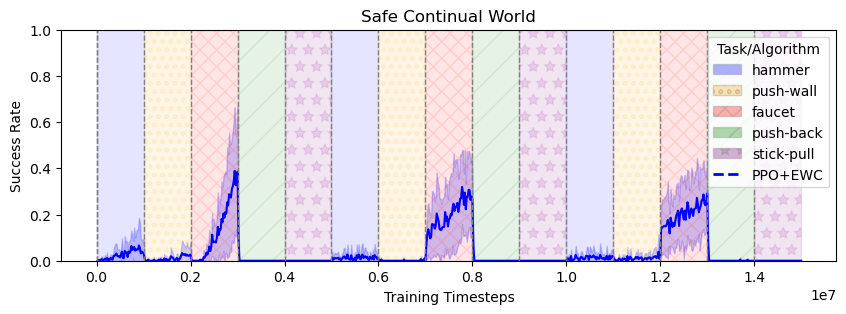

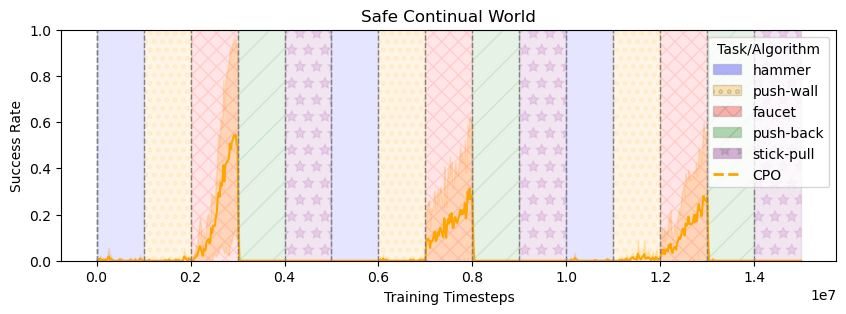

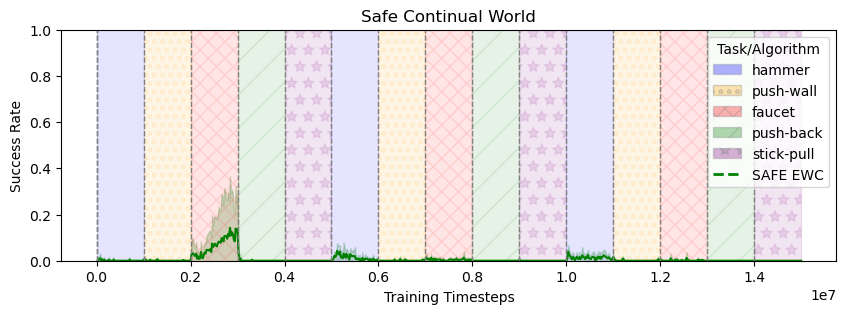

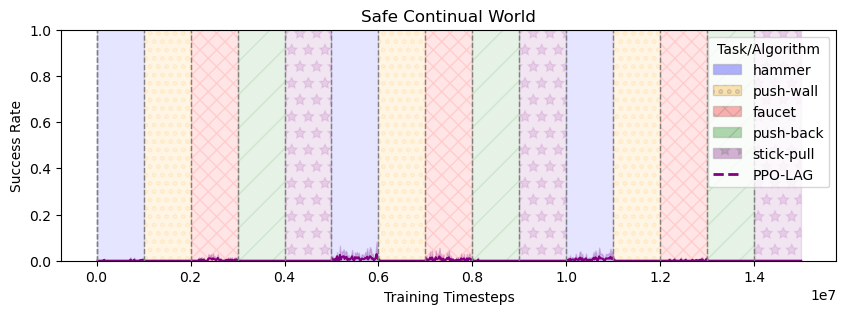

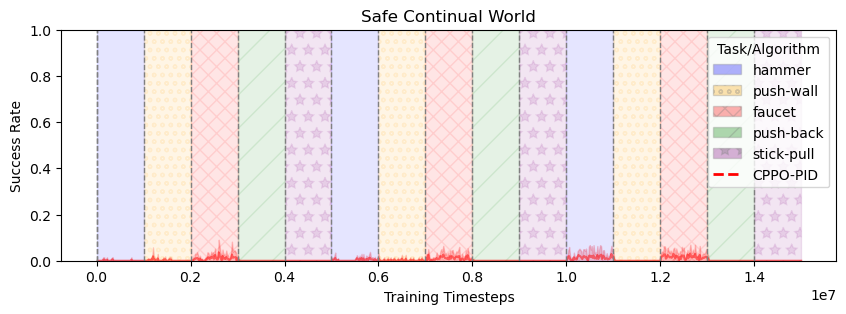

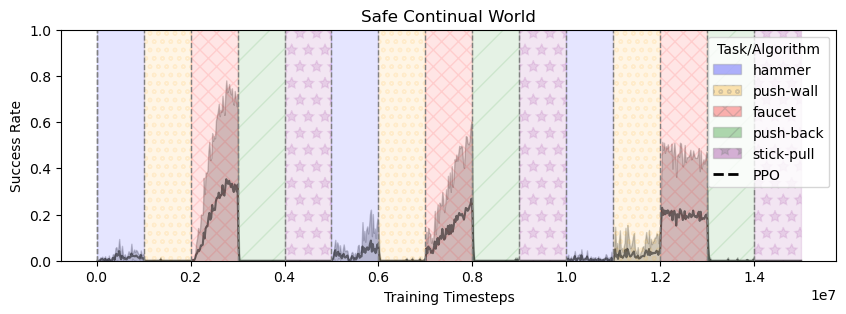

In [96]:
algorithms = ['PPO+EWC', 'CPO', 'Safe EWC', 'PPO-Lag', 'CPPO-PID', 'PPO']
for algorithm in algorithms:
    plot_rewards([algorithm], 1, True, f'{algorithm}_cw_success')

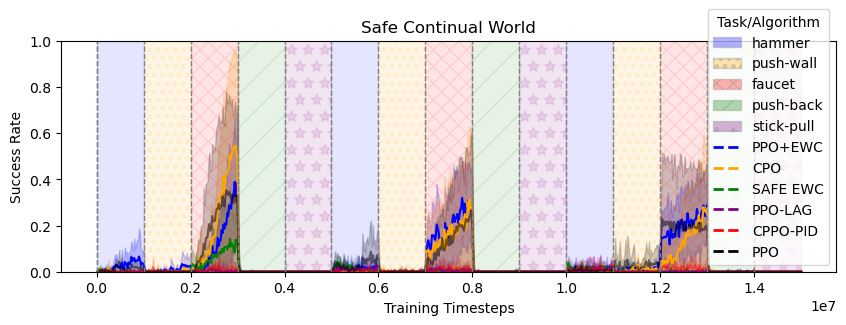

In [98]:
plot_rewards(algorithms, 1, True, f'all_cw_success')

In [ ]:
def plot_costs(algorithms, ymax=None, save=False, name=None, xrange=None):
    fig, ax = plt.subplots(figsize=(10,1)) 
    # plt.figure()
    # plt.figure(figsize=(3,3))

    TASK_CYCLE =  ['hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull', 
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull',
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull']
    algorithm_colors={'PPO+EWC': 'blue', 
                    'CPO': 'orange',
                    'Safe EWC': 'green',
                    'PPO-Lag': 'purple',
                    'CPPO-PID': 'red',
                    'PPO': 'black',
                    'Exp. Replay': 'brown'}
    cycle_colors = {
        'hammer': 'blue',
        'push-wall': 'orange',
        'faucet': 'red',
        'push-back': 'green',
        'stick-pull': 'purple'
    }

    cycle_hatches = {
        'hammer': '',
        'push-wall': 'oo',
        'faucet': 'xx',
        'push-back': '/',
        'stick-pull': '*'
    }

    if 'PPO+EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_ewc_mean_costs, label='PPO+EWC', color='blue')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_ewc_mean_costs - cw_ewc_std_costs,
            cw_ewc_mean_costs + cw_ewc_std_costs,
            color='blue', alpha=0.2
        )

    if 'CPO' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_cpo_mean_costs, label='CPO', color='orange')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_cpo_mean_costs - cw_cpo_std_costs,
            cw_cpo_mean_costs + cw_cpo_std_costs,
            color='orange', alpha=0.2
        )

    if 'Safe EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], safe_ewc_mean_costs, label='Safe EWC', color='green')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            safe_ewc_mean_costs - safe_ewc_std_costs,
            safe_ewc_mean_costs + safe_ewc_std_costs,
            color='green', alpha=0.2
        )

    if 'PPO-Lag' in algorithms:
        plt.plot(cw_ppolag_0['Train/TotalSteps'], cw_ppolag_mean_costs, label='PPO-Lag', color='purple')
        plt.fill_between(
            cw_ppolag_0['Train/TotalSteps'],
            cw_ppolag_mean_costs - cw_ppolag_std_costs,
            cw_ppolag_mean_costs + cw_ppolag_std_costs,
            color='purple', alpha=0.2
        )

    if 'CPPO-PID' in algorithms:
        plt.plot(cw_cppo_pid_0['Train/TotalSteps'], cw_cppo_pid_mean_costs, label='CPPO-PID', color='red', alpha=0.5)
        plt.fill_between(
            cw_cppo_pid_0['Train/TotalSteps'],
            cw_cppo_pid_mean_costs - cw_cppo_pid_std_costs,
            cw_cppo_pid_mean_costs + cw_cppo_pid_std_costs,
            color='red', alpha=0.2
        )

    if 'PPO' in algorithms:
        plt.plot(cw_ppo_0['Train/TotalSteps'], cw_ppo_mean_costs, label='PPO', color='black', alpha=0.5)
        plt.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_ppo_mean_costs - cw_ppo_std_costs,
            cw_ppo_mean_costs + cw_ppo_std_costs,
            color='black', alpha=0.2
        )

    if 'Exp. Replay' in algorithms:
        plt.plot(cw_clear_0['Train/TotalSteps'], cw_clear_mean_costs, label='Exp. Replay', color='brown', alpha=0.5)
        plt.fill_between(
            cw_clear_0['Train/TotalSteps'],
            cw_clear_mean_costs - cw_clear_std_costs,
            cw_clear_mean_costs + cw_clear_std_costs,
            color='brown', alpha=0.2
        )

    x_vals = range(0, max(cw_cpo_0['Train/TotalSteps']) + 1, 1000000)
    for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
        # Get the current task from the cycle
        task = TASK_CYCLE[i % len(TASK_CYCLE)]
        
        # Shade the region between the current and next x value
        plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
        plt.fill_between([x, x_vals[i + 1]], cw_ewc_0['Metrics/EpCost'].min(), cw_ewc_0['Metrics/EpCost'].max(), color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

    legend_patches = []
    for task in cycle_colors:
        patch = mpatches.Patch(
            facecolor=cycle_colors[task], 
            hatch=cycle_hatches[task], 
            label=task,
            edgecolor='gray',  # Optional: add edgecolor to improve visibility in legend,
            alpha=0.3
        )
        legend_patches.append(patch)

    for algorithm in algorithms:
        custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='-', label=algorithm.upper())
        legend_patches.append(custom_line)
    # Add legend to the plot
    plt.legend(handles=legend_patches, title='Task/Algorithm', loc='lower center', bbox_to_anchor=(0.5, -1.6), ncol=7, shadow=True, columnspacing=0.6)

    plt.xlabel("Training Timesteps")
    plt.ylabel("Cost")
    plt.title("Safe Continual World")
    if ymax is not None:
        plt.ylim(0, ymax)
    # plt.yscale('log')

    from matplotlib.ticker import ScalarFormatter

    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # Apply scientific notation to y-axis
    if xrange is not None:
        plt.xlim(xrange[0], xrange[1])

    if save:
        plt.savefig(f'./results/plots/{name}.png', bbox_inches='tight')

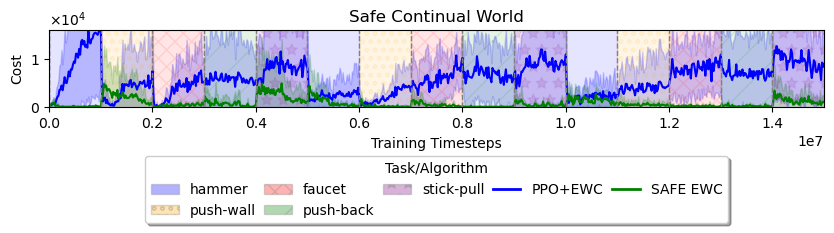

In [218]:
plot_costs(['PPO+EWC', 'Safe EWC'], 16000, True, 'cw_cost', (0, 15_000_000))

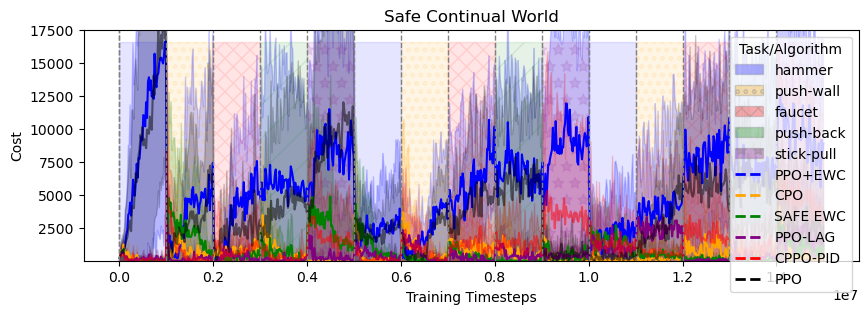

In [65]:
algorithms = ['PPO+EWC', 'CPO', 'Safe EWC', 'PPO-Lag', 'CPPO-PID', 'PPO']
plot_costs(algorithms, 17500, True, 'all_cw_cost')

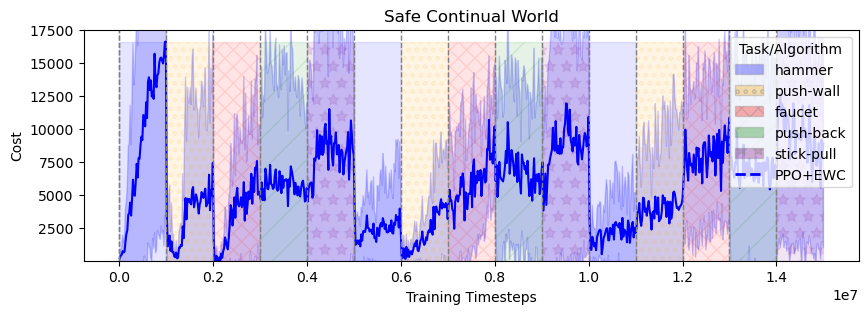

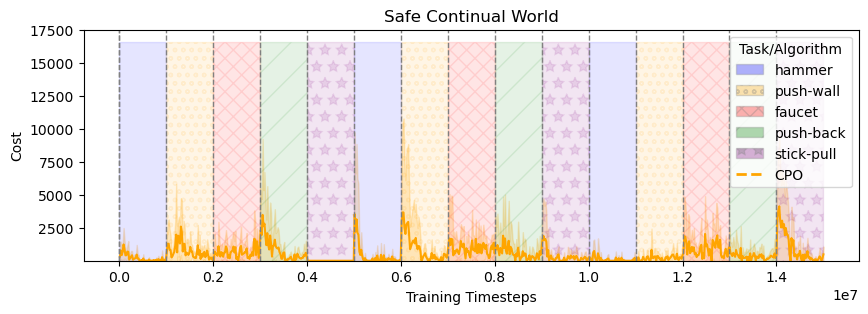

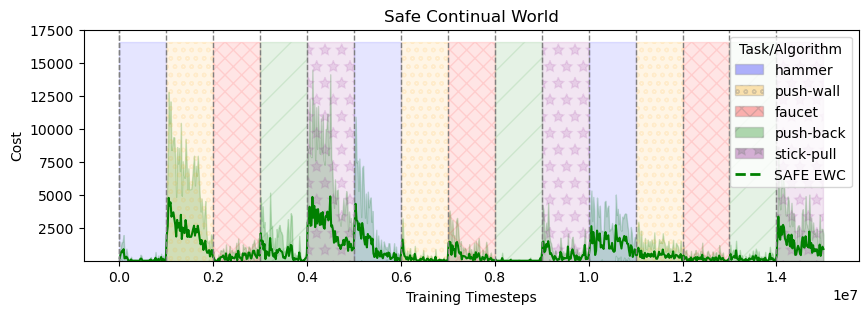

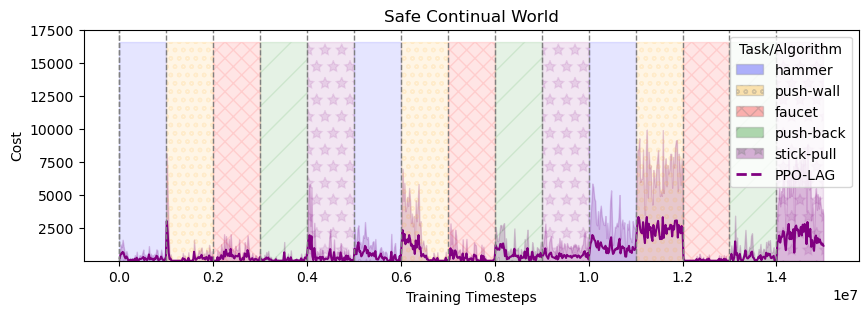

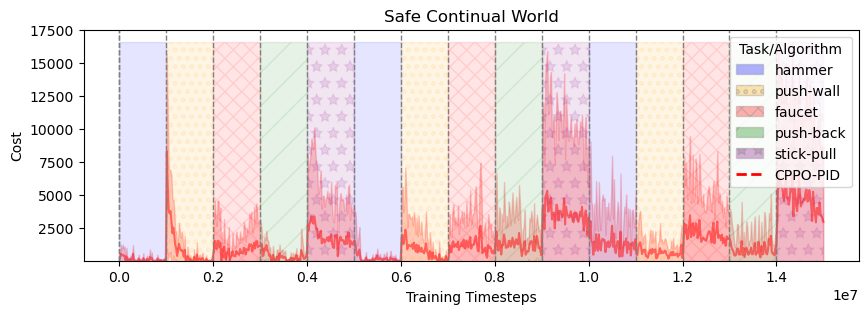

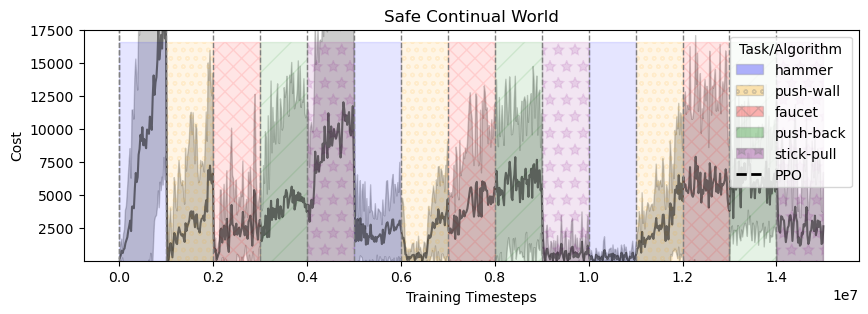

In [66]:
algorithms = ['PPO+EWC', 'CPO', 'Safe EWC', 'PPO-Lag', 'CPPO-PID', 'PPO']
for algorithm in algorithms:
    plot_costs([algorithm], 17500, True, f'{algorithm}_cw_cost')

In [128]:
def plot_costs_task_change(algorithms, ymax=None, save=False, name=None, xrange=None):
    # plt.figure(figsize=(10,3))
    plt.figure(figsize=(3,3))

    TASK_CYCLE =  ['hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull', 
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull',
                     'hammer', 'push-wall', 'faucet', 'push-back', 'stick-pull']
    algorithm_colors={'PPO+EWC': 'blue', 
                    'CPO': 'orange',
                    'Safe EWC': 'green',
                    'PPO-Lag': 'purple',
                    'CPPO-PID': 'red',
                    'PPO': 'black',
                    'Exp. Replay': 'brown'}
    cycle_colors = {
        'hammer': 'blue',
        'push-wall': 'orange',
        'faucet': 'red',
        'push-back': 'green',
        'stick-pull': 'purple'
    }

    cycle_hatches = {
        'hammer': '',
        'push-wall': 'oo',
        'faucet': 'xx',
        'push-back': '/',
        'stick-pull': '*'
    }

    if 'PPO+EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_ewc_mean_costs, label='PPO+EWC', color='blue')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_ewc_mean_costs - cw_ewc_std_costs,
            cw_ewc_mean_costs + cw_ewc_std_costs,
            color='blue', alpha=0.2
        )

    if 'CPO' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], cw_cpo_mean_costs, label='CPO', color='orange')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            cw_cpo_mean_costs - cw_cpo_std_costs,
            cw_cpo_mean_costs + cw_cpo_std_costs,
            color='orange', alpha=0.2
        )

    if 'Safe EWC' in algorithms:
        plt.plot(cw_cpo_0['Train/TotalSteps'], safe_ewc_mean_costs, label='Safe EWC', color='green')
        plt.fill_between(
            cw_cpo_0['Train/TotalSteps'],
            safe_ewc_mean_costs - safe_ewc_std_costs,
            safe_ewc_mean_costs + safe_ewc_std_costs,
            color='green', alpha=0.2
        )

    if 'PPO-Lag' in algorithms:
        plt.plot(cw_ppolag_0['Train/TotalSteps'], cw_ppolag_mean_costs, label='PPO-Lag', color='purple')
        plt.fill_between(
            cw_ppolag_0['Train/TotalSteps'],
            cw_ppolag_mean_costs - cw_ppolag_std_costs,
            cw_ppolag_mean_costs + cw_ppolag_std_costs,
            color='purple', alpha=0.2
        )

    if 'CPPO-PID' in algorithms:
        plt.plot(cw_cppo_pid_0['Train/TotalSteps'], cw_cppo_pid_mean_costs, label='CPPO-PID', color='red', alpha=0.5)
        plt.fill_between(
            cw_cppo_pid_0['Train/TotalSteps'],
            cw_cppo_pid_mean_costs - cw_cppo_pid_std_costs,
            cw_cppo_pid_mean_costs + cw_cppo_pid_std_costs,
            color='red', alpha=0.2
        )

    if 'PPO' in algorithms:
        plt.plot(cw_ppo_0['Train/TotalSteps'], cw_ppo_mean_costs, label='PPO', color='black', alpha=0.5)
        plt.fill_between(
            cw_ppo_0['Train/TotalSteps'],
            cw_ppo_mean_costs - cw_ppo_std_costs,
            cw_ppo_mean_costs + cw_ppo_std_costs,
            color='black', alpha=0.2
        )

    if 'Exp. Replay' in algorithms:
        plt.plot(cw_clear_0['Train/TotalSteps'], cw_clear_mean_costs, label='Exp. Replay', color='brown', alpha=0.5)
        plt.fill_between(
            cw_clear_0['Train/TotalSteps'],
            cw_clear_mean_costs - cw_clear_std_costs,
            cw_clear_mean_costs + cw_clear_std_costs,
            color='brown', alpha=0.2
        )

    x_vals = range(0, max(cw_cpo_0['Train/TotalSteps']) + 1, 1000000)
    for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
        # Get the current task from the cycle
        task = TASK_CYCLE[i % len(TASK_CYCLE)]
        
        # Shade the region between the current and next x value
        plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
        plt.fill_between([x, x_vals[i + 1]], cw_ewc_0['Metrics/EpCost'].min(), cw_ewc_0['Metrics/EpCost'].max(), color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

    legend_patches = []
    # for task in cycle_colors:
    #     patch = mpatches.Patch(
    #         facecolor=cycle_colors[task], 
    #         hatch=cycle_hatches[task], 
    #         label=task,
    #         edgecolor='gray',  # Optional: add edgecolor to improve visibility in legend,
    #         alpha=0.3
    #     )
    #     legend_patches.append(patch)

    for algorithm in algorithms:
        custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='--', label=algorithm.upper())
        legend_patches.append(custom_line)
    # Add legend to the plot
    plt.legend(handles=legend_patches, title='Algorithm', loc='upper left')

    plt.xlabel("Training Timesteps")
    plt.ylabel("Cost")
    plt.title("Cost at Task Change")
    if ymax is not None:
        plt.ylim(0, ymax)
    # plt.yscale('log')

    if xrange is not None:
        plt.xlim(xrange[0], xrange[1])

    if save:
        plt.savefig(f'./results/plots/{name}.png', bbox_inches='tight')

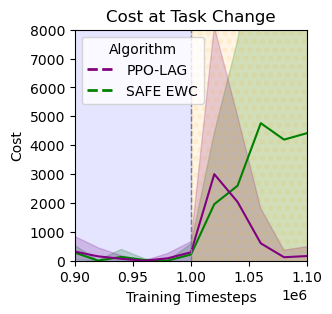

In [129]:
plot_costs_task_change(['PPO-Lag', 'Safe EWC'], 8000, True, 'cost_task_change', (900_000, 1_100_000))